最新数据日期：2025-07-18
             open   high    low  close     volume
2025-07-14  48.79  49.76  48.50  49.09  1260092.0
2025-07-15  48.99  49.34  47.61  48.00  1861332.0
2025-07-16  48.10  48.47  44.80  46.27  4924786.0
2025-07-17  46.08  47.48  46.00  46.31  2384270.0
2025-07-18  46.56  46.60  45.90  46.27  1506605.0
找到的中枢线: [46.33444444444444, 48.740645161290324, 53.59518518518519]
找到的中枢区域: [(46.33444444444444, 45.987142857142864, 46.65428571428571, 7), (48.740645161290324, 48.201764705882354, 49.021764705882354, 17), (53.59518518518519, 52.734166666666674, 53.48583333333334, 12)]
找到的反转点数量: 73
找到的成交量极值点数量: 3


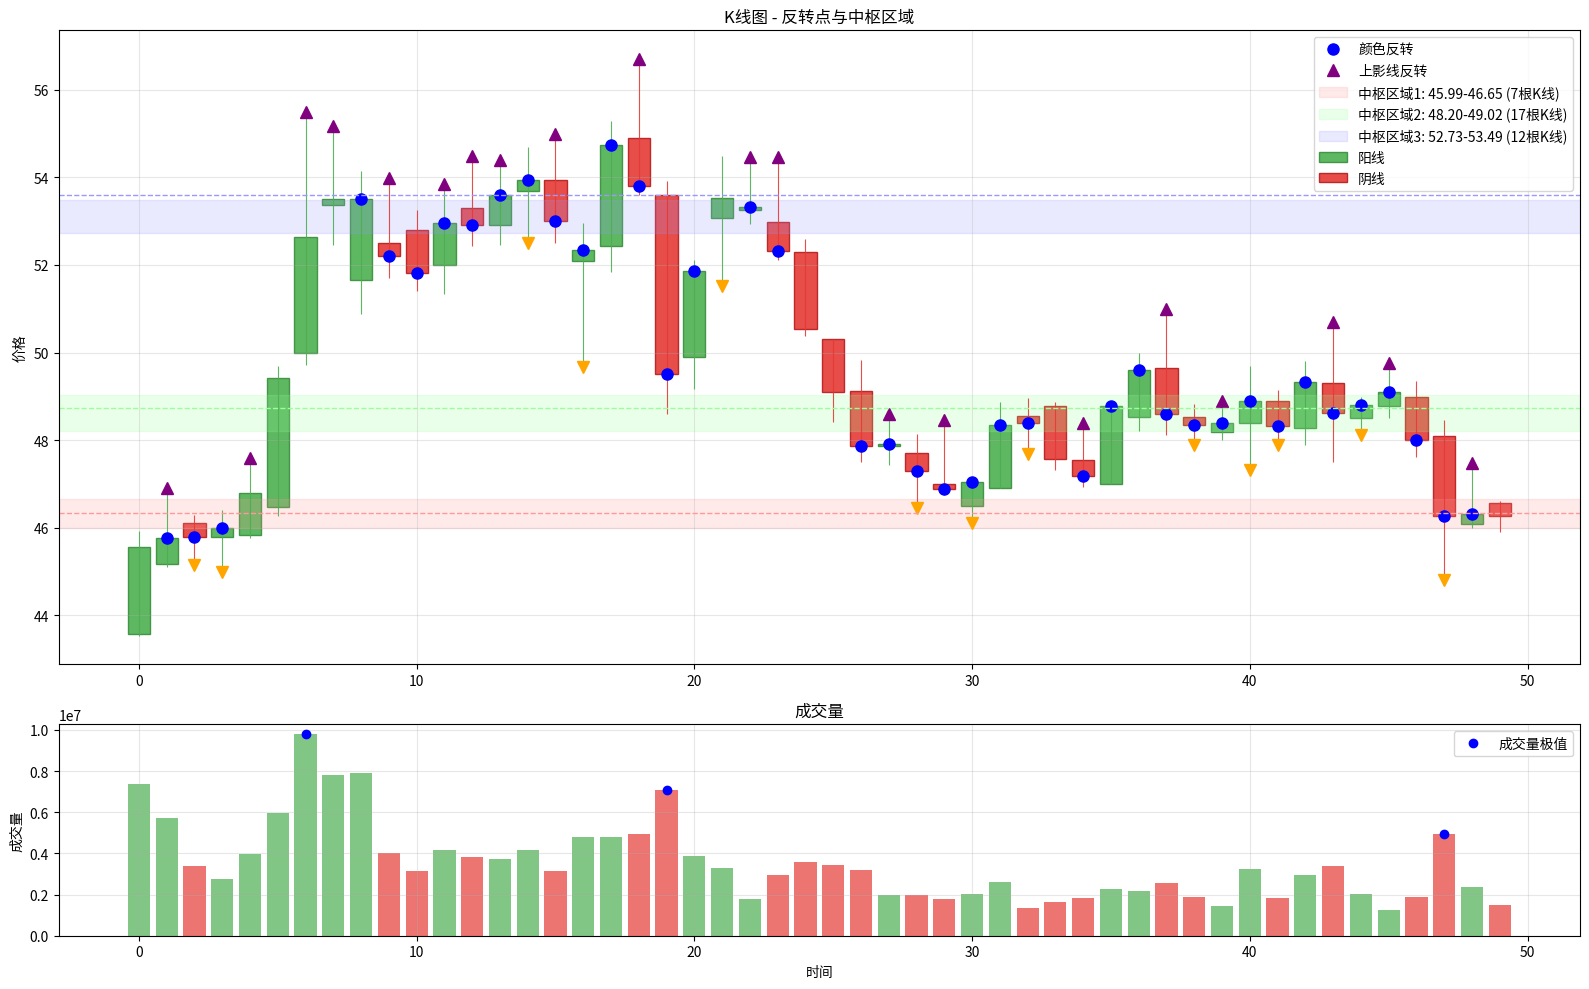

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
import argparse
from matplotlib.dates import DateFormatter
from matplotlib.patches import Rectangle
from matplotlib import gridspec
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans


class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation  # 最小区域分离度（价格范围的百分比）
        self.max_zone_width_ratio = max_zone_width_ratio  # 最大区域宽度比例（相对于价格范围）
        self.entity_size_threshold = entity_size_threshold  # 实体大小阈值（过滤异常大实体K线）
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            # 记录成交量极值点对应的K线收盘价
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=3):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        # 1. 找K线反转点
        reversal_points = self.find_reversal_points(df)
        
        # 2. 找成交量极值点对应的K线价格
        volume_points = self.find_volume_price_points(df)
        
        # 合并所有价格点
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        # 3. 对价格进行聚类，找出最多3条水平线
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域（基于穿过中枢线的K线实体范围），确保区域不重叠且宽度合理"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        # 计算价格范围，用于确定最小分离距离和最大区域宽度
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        # 计算实体大小的阈值（过滤异常大实体K线）
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)  # 使用95%分位数作为阈值
        
        for center_line in center_lines:
            # 找出所有穿过中枢线的K线
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    # 计算实体最高和最低点
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    # 过滤异常大的实体K线
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                # 计算实体最高点的平均值和实体最低点的平均值
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                # 确保区域高度合理（至少有一定最小高度）
                min_zone_height = price_range * 0.005  # 最小高度为价格范围的0.5%
                if zone_high - zone_low < min_zone_height:
                    # 如果区域太窄，扩展它
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                # 限制区域最大宽度
                if zone_high - zone_low > max_zone_width:
                    # 如果区域太宽，限制它
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                # 检查是否与现有区域重叠
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域（但限制合并后的宽度）
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        # 限制合并后的区域宽度
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        # 更新现有区域
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    # 没有重叠，添加新区域
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离
        center_zones.sort(key=lambda x: x[0])  # 按中心线排序
        
        for i in range(len(center_zones) - 1):
            current_high = center_zones[i][2]
            next_low = center_zones[i + 1][1]
            
            if current_high + min_separation > next_low:
                # 调整区域边界以确保最小分离
                midpoint = (current_high + next_low) / 2
                center_zones[i] = (
                    center_zones[i][0], 
                    center_zones[i][1], 
                    midpoint - min_separation / 2,
                    center_zones[i][3]
                )
                center_zones[i + 1] = (
                    center_zones[i + 1][0], 
                    midpoint + min_separation / 2, 
                    center_zones[i + 1][2],
                    center_zones[i + 1][3]
                )
        
        return center_zones
    
    def plot_kline_with_zones(self, df, center_zones, reversal_points, volume_points, save_path=None):
        """
        绘制K线图和成交量图，并标记反转点和中枢区域
        
        参数:
        df: DataFrame，包含以下列：'open', 'high', 'low', 'close', 'volume'
        center_zones: 中枢区域列表，每个元素为(中心线, 下边界, 上边界, 包含K线数)
        reversal_points: 反转点列表
        volume_points: 成交量极值点列表
        save_path: 图片保存路径（可选）
        """
        # 确保数据格式正确
        required_columns = ['open', 'high', 'low', 'close', 'volume']
        if not all(col in df.columns for col in required_columns):
            raise ValueError("DataFrame必须包含'open', 'high', 'low', 'close', 'volume'列")
        
        # 创建图表和子图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})
        
        # 创建数值索引
        x = np.arange(len(df))
        
        # 提取价格数据
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        volumes = df['volume'].values
        
        # ------ 绘制K线 ------
        # 分离阳线和阴线
        up_indices = closes >= opens
        down_indices = closes < opens
        
        # 阳线 (现代绿色)
        if np.any(up_indices):
            up_x = x[up_indices]
            up_highs = highs[up_indices]
            up_lows = lows[up_indices]
            up_opens = opens[up_indices]
            up_closes = closes[up_indices]
            
            # 绘制影线
            ax1.vlines(up_x, up_lows, up_highs, color='#4CAF50', linewidth=0.8, alpha=0.9)
            # 绘制实体
            ax1.bar(up_x, up_closes - up_opens, 0.8, up_opens, 
                   color='#4CAF50', edgecolor='#388E3C', alpha=0.9, label='阳线')
        
        # 阴线 (现代红色)
        if np.any(down_indices):
            down_x = x[down_indices]
            down_highs = highs[down_indices]
            down_lows = lows[down_indices]
            down_opens = opens[down_indices]
            down_closes = closes[down_indices]
            
            # 绘制影线
            ax1.vlines(down_x, down_lows, down_highs, color='#E53935', linewidth=0.8, alpha=0.9)
            # 绘制实体
            ax1.bar(down_x, down_closes - down_opens, 0.8, down_opens, 
                   color='#E53935', edgecolor='#B71C1C', alpha=0.9, label='阴线')
        
        # 标记反转点
        for point_type, idx, price in reversal_points:
            if point_type == 'color_reversal':
                ax1.plot(x[idx], price, 'o', color='blue', markersize=8, 
                        label='颜色反转' if idx == reversal_points[0][1] else "")
            elif point_type == 'upper_shadow':
                ax1.plot(x[idx], price, '^', color='purple', markersize=8, 
                        label='上影线反转' if idx == reversal_points[0][1] else "")
            elif point_type == 'lower_shadow':
                ax1.plot(x[idx], price, 'v', color='orange', markersize=8, 
                        label='下影线反转' if idx == reversal_points[0][1] else "")
        
        # 绘制中枢区域
        colors = ['#FF9999', '#99FF99', '#9999FF']  # 不同中枢区域使用不同颜色
        for i, (center_line, zone_low, zone_high, k_line_count) in enumerate(center_zones):
            # 绘制区域
            ax1.axhspan(zone_low, zone_high, alpha=0.2, color=colors[i % len(colors)],
                       label=f'中枢区域{i+1}: {zone_low:.2f}-{zone_high:.2f} ({k_line_count}根K线)')
            
            # 绘制中心线
            ax1.axhline(y=center_line, color=colors[i % len(colors)], linestyle='--', linewidth=1)
        
        # 设置K线图标题和标签
        ax1.set_title('K线图 - 反转点与中枢区域')
        ax1.set_ylabel('价格')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # ------ 绘制成交量 ------
        # 分离阳线和阴线的成交量
        up_volumes = volumes[up_indices]
        down_volumes = volumes[down_indices]
        
        # 阳线成交量 (绿色)
        if np.any(up_indices):
            ax2.bar(x[up_indices], up_volumes, 0.8, color='#4CAF50', alpha=0.7)
        
        # 阴线成交量 (红色)
        if np.any(down_indices):
            ax2.bar(x[down_indices], down_volumes, 0.8, color='#E53935', alpha=0.7)
        
        # 标记成交量极值点
        for point_type, idx, price in volume_points:
            ax2.plot(x[idx], volumes[idx], 'o', color='blue', markersize=6, 
                    label='成交量极值' if idx == volume_points[0][1] else "")
        
        # 设置成交量图标题和标签
        ax2.set_title('成交量')
        ax2.set_ylabel('成交量')
        ax2.set_xlabel('时间')
        ax2.grid(True, alpha=0.3)
        
        # 添加图例（只添加一次）
        if len(volume_points) > 0:
            ax2.legend()
        
        # 调整布局
        plt.tight_layout()
        
        # 保存图片（如果提供了保存路径）
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"图片已保存至: {save_path}")
        
        plt.show()


    





    # ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300973.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20250720',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=50,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    
    
    # 创建分析器实例
    analyzer = KLineCenterAnalyzer(
        window=5, 
        shadow_ratio=0.7, 
        min_zone_separation=0.02,
        max_zone_width_ratio=0.1,  # 最大区域宽度为价格范围的10%
        entity_size_threshold=0.05  # 实体大小阈值
    )
    
    # 计算中枢线
    center_lines, reversal_points, volume_points = analyzer.find_centers(df)
    
    # 计算中枢区域
    center_zones = analyzer.calculate_center_zones(df, center_lines)
    
    print("找到的中枢线:", center_lines)
    print("找到的中枢区域:", center_zones)
    print("找到的反转点数量:", len(reversal_points))
    print("找到的成交量极值点数量:", len(volume_points))
    
    # 绘制K线图和成交量图
    analyzer.plot_kline_with_zones(df, center_zones, reversal_points, volume_points)